# Covid-19 in South Korea

- To which region side of Seoul did virus spread the fastest and what might impacted it?
- Is treatment at home is effective as in hospital?
- In average how many people is infected by one person?

## Dataset import (format: alt + shift + F)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.dates import MonthLocator
import seaborn as sns
from functions_sandbox import cleaner

path = r"D:\IT_projects\Turing_Colledge\Modul1\Sprint4\project"

case = pd.read_csv(path + r"\Case.csv")
patient_info = pd.read_csv(path + r"\PatientInfo.csv")
policy = pd.read_csv(path + r"\Policy.csv")
region = pd.read_csv(path + r"\Region.csv")
search_trend = pd.read_csv(path + r"\SearchTrend.csv")
seoul_floating = pd.read_csv(path + r"\SeoulFloating.csv")
time = pd.read_csv(path + r"\Time.csv")
time_age = pd.read_csv(path + r"\TimeAge.csv")
time_gender = pd.read_csv(path + r"\TimeGender.csv")
time_province = pd.read_csv(path + r"\TimeProvince.csv")
weather = pd.read_csv(path + r"\Weather.csv")

all_tables = [
    {"case": case},
    {"patient_info": patient_info},
    {"policy": policy},
    {"region": region},
    {"search_trend": search_trend},
    {"seoul_floating": seoul_floating},
    {"time": time},
    {"time_age": time_age},
    {"time_gender": time_gender},
    {"time_province": time_province},
    {"weather": weather},
]

### First look

In [2]:
shape_table = [(list(table.keys())[0], list(table.values())[0].shape) for table in all_tables]
for look in shape_table:
    print(look)

('case', (174, 8))
('patient_info', (5165, 14))
('policy', (61, 7))
('region', (244, 12))
('search_trend', (1642, 5))
('seoul_floating', (1084800, 7))
('time', (163, 7))
('time_age', (1089, 5))
('time_gender', (242, 5))
('time_province', (2771, 6))
('weather', (26271, 10))


In [3]:
weather.head(3)
#case: latitude, longitude to float;
#patient_info: many NaNs in various columns;
#policy: difficult to analise;
#region: very clean to analyse;
#search_trend: wrong dtype for date; nice table to analyse;
#seoul_floating: wrong dtype for date; what is fp_num?, birth_year?;
#time: should time be days?; dtype for date is wrong;
#time_age: wrong dtype for date; strange time; 
#time_gender: dtype for date; looks like random table;
#time_province: dtype for date; decent;
#weather: dtype for date; some of NaNs exists; interesting perspective to analyse;

,code,province,date,avg_temp,min_temp,max_temp,precipitation,max_wind_speed,most_wind_direction,avg_relative_humidity
0,10000,Seoul,2016-01-01,1.2,-3.3,4.0,0.0,3.5,90.0,73.0
1,11000,Busan,2016-01-01,5.3,1.1,10.9,0.0,7.4,340.0,52.1
2,12000,Daegu,2016-01-01,1.7,-4.0,8.0,0.0,3.7,270.0,70.5


In [4]:
time_province.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2771 entries, 0 to 2770
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   date       2771 non-null   object
 1   time       2771 non-null   int64 
 2   province   2771 non-null   object
 3   confirmed  2771 non-null   int64 
 4   released   2771 non-null   int64 
 5   deceased   2771 non-null   int64 
dtypes: int64(4), object(2)
memory usage: 130.0+ KB


### TimeProvince data preparation/cleaning

In [5]:
clean_time_province = cleaner(time_province, info=False)
clean_time_province["date"] = pd.to_datetime(clean_time_province["date"])
clean_time_province.sort_values(by="date", ascending=True, inplace=True)
clean_time_province["week"] = clean_time_province["date"].dt.isocalendar().week
clean_time_province.head(5)

,date,time,province,confirmed,released,deceased,week
0,2020-01-20,16,Seoul,0,0,0,4
16,2020-01-20,16,Jeju-do,0,0,0,4
15,2020-01-20,16,Gyeongsangnam-do,0,0,0,4
14,2020-01-20,16,Gyeongsangbuk-do,0,0,0,4
13,2020-01-20,16,Jeollanam-do,0,0,0,4


### Time data preparation/cleaning

In [104]:
clean_time = cleaner(time, info=False)
clean_time.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 163 entries, 0 to 162
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   date       163 non-null    object
 1   time       163 non-null    int64 
 2   test       163 non-null    int64 
 3   negative   163 non-null    int64 
 4   confirmed  163 non-null    int64 
 5   released   163 non-null    int64 
 6   deceased   163 non-null    int64 
dtypes: int64(6), object(1)
memory usage: 9.0+ KB


In [108]:
clean_time["date"] = pd.to_datetime(clean_time["date"])
clean_time.sort_values(by="date", ascending=True, inplace=True)
clean_time

,date,time,test,negative,confirmed,released,deceased
0,2020-01-20,16,1,0,1,0,0
1,2020-01-21,16,1,0,1,0,0
2,2020-01-22,16,4,3,1,0,0
3,2020-01-23,16,22,21,1,0,0
4,2020-01-24,16,27,25,2,0,0
...,...,...,...,...,...,...,...
158,2020-06-26,0,1232315,1200885,12602,11172,282
159,2020-06-27,0,1243780,1211261,12653,11317,282
160,2020-06-28,0,1251695,1219975,12715,11364,282
161,2020-06-29,0,1259954,1228698,12757,11429,282


### TimeAge data preparation/cleaning

In [6]:
clean_time_age = cleaner(time_age, info=False)
clean_time_age.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1089 entries, 0 to 1088
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   date       1089 non-null   object
 1   time       1089 non-null   int64 
 2   age        1089 non-null   object
 3   confirmed  1089 non-null   int64 
 4   deceased   1089 non-null   int64 
dtypes: int64(3), object(2)
memory usage: 42.7+ KB


In [165]:
clean_time_age["date"] = pd.to_datetime(clean_time_age["date"])
clean_time_age.sort_values(by="date", ascending=True, inplace=True)

diff_time_age = clean_time_age.groupby("age")["confirmed"].diff()
clean_time_age["daily_confirmed"] = diff_time_age
clean_time_age["daily_confirmed"] = clean_time_age["daily_confirmed"].fillna(0).astype(int)

cumsum_time_age = clean_time_age.groupby("age")["daily_confirmed"].cumsum()
clean_time_age["confirmed_cumsum"] = cumsum_time_age
clean_time_age

,date,time,age,confirmed,deceased,daily_confirmed,confirmed_cumsum
0,2020-03-02,0,0s,32,0,0,0
1,2020-03-02,0,10s,169,0,0,0
2,2020-03-02,0,20s,1235,0,0,0
3,2020-03-02,0,30s,506,1,0,0
4,2020-03-02,0,40s,633,1,0,0
...,...,...,...,...,...,...,...
1083,2020-06-30,0,30s,1496,2,6,990
1084,2020-06-30,0,40s,1681,3,8,1048
1085,2020-06-30,0,50s,2286,15,6,1452
1086,2020-06-30,0,60s,1668,41,3,1138


### TimeGender data preparation/cleaning

In [8]:
clean_time_gender = cleaner(time_gender, info=False)
clean_time_gender.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 242 entries, 0 to 241
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   date       242 non-null    object
 1   time       242 non-null    int64 
 2   sex        242 non-null    object
 3   confirmed  242 non-null    int64 
 4   deceased   242 non-null    int64 
dtypes: int64(3), object(2)
memory usage: 9.6+ KB


In [9]:
clean_time_gender["date"] = pd.to_datetime(clean_time_gender["date"])
clean_time_gender.sort_values(by="date", ascending=True, inplace=True)
clean_time_gender

,date,time,sex,confirmed,deceased
0,2020-03-02,0,male,1591,13
1,2020-03-02,0,female,2621,9
2,2020-03-03,0,male,1810,16
3,2020-03-03,0,female,3002,12
4,2020-03-04,0,male,1996,20
...,...,...,...,...,...
237,2020-06-28,0,female,7265,131
238,2020-06-29,0,male,5470,151
239,2020-06-29,0,female,7287,131
240,2020-06-30,0,male,5495,151


## EDA (Exploratory Data Analysis)

### Virus spreading in provinces

In [142]:
unique_provinces = clean_time_province["province"].unique()
grouped_provinces = (
    clean_time_province.groupby("province")
    .agg({"confirmed": "max", "released": "max", "deceased": "max"})
    .sort_values(by="confirmed", ascending=False)
    .reset_index()
)
date_start = clean_time_province["date"].min()
date_end = clean_time_province["date"].max()

print(f"There are {len(unique_provinces)} unique provinces\n")
print(f"Date when tracking was started: {date_start}")
print(f"Date when tracking was ended: {date_end}\n")
print(grouped_provinces)

There are 17 unique provinces

Date when tracking was started: 2020-01-20 00:00:00
Date when tracking was ended: 2020-06-30 00:00:00

             province  confirmed  released  deceased
0               Daegu       6906      6700       189
1    Gyeongsangbuk-do       1389      1328        54
2               Seoul       1312       985         7
3         Gyeonggi-do       1207       931        23
4             Incheon        341       290         2
5   Chungcheongnam-do        167       150         0
6               Busan        154       143         3
7    Gyeongsangnam-do        134       128         0
8             Daejeon        117        44         1
9   Chungcheongbuk-do         65        60         0
10         Gangwon-do         65        54         3
11              Ulsan         55        50         1
12             Sejong         50        47         0
13            Gwangju         44        32         0
14       Jeollabuk-do         27        21         0
15       Jeollanam

In [145]:
top_names = list(grouped_provinces["province"][:5])
top_five = clean_time_province[clean_time_province["province"].isin(top_names)]
top_five_df = top_five.copy()
grouped = top_five_df.groupby("province")["confirmed"].diff()
top_five_df["daily_confirmed"] = grouped
top_five_df

,date,time,province,confirmed,released,deceased,week,daily_confirmed
0,2020-01-20,16,Seoul,0,0,0,4,NaN
14,2020-01-20,16,Gyeongsangbuk-do,0,0,0,4,NaN
3,2020-01-20,16,Incheon,1,0,0,4,NaN
2,2020-01-20,16,Daegu,0,0,0,4,NaN
8,2020-01-20,16,Gyeonggi-do,0,0,0,4,NaN
...,...,...,...,...,...,...,...,...
2768,2020-06-30,0,Gyeongsangbuk-do,1389,1328,54,27,1.0
2762,2020-06-30,0,Gyeonggi-do,1207,931,23,27,7.0
2757,2020-06-30,0,Incheon,341,290,1,27,3.0
2756,2020-06-30,0,Daegu,6906,6700,189,27,0.0


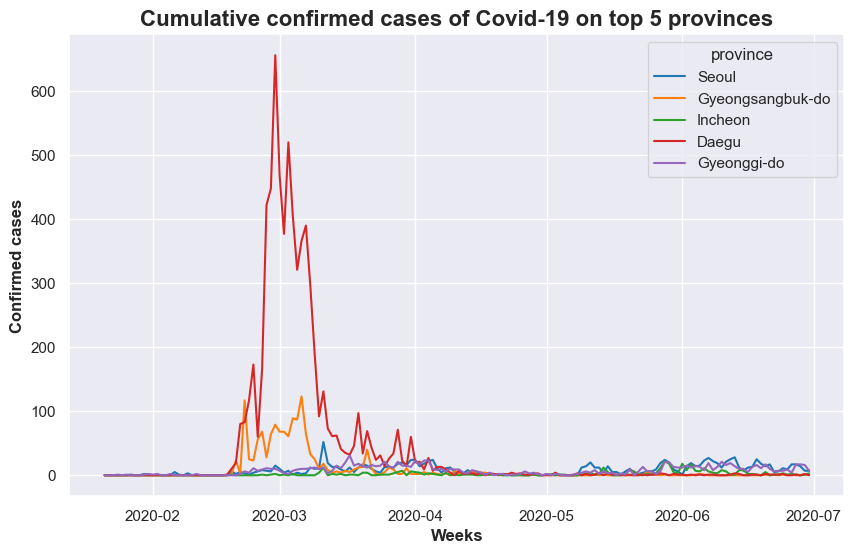

In [146]:
sns.set_style("darkgrid")
sns.set_context("notebook")
fig, ax = plt.subplots(figsize=(10, 6))
sns.lineplot(data=top_five_df, x="date", y=top_five_df["daily_confirmed"], hue="province")

plt.xlabel("Weeks", fontweight="bold")
plt.ylabel("Daily confirmed cases", fontweight="bold")
plt.title("Cumulative confirmed cases of Covid-19 on top 5 provinces", fontweight="bold", fontsize=16)

plt.show()

### Covid-19 tests

Correlation of various cases

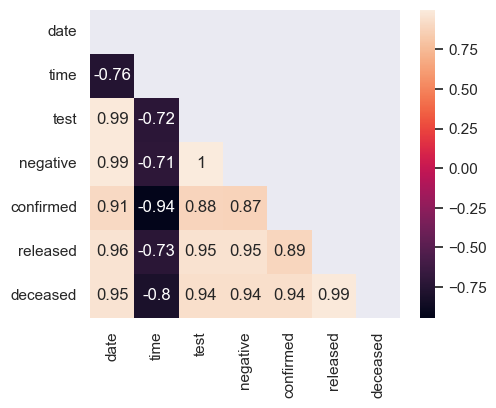

In [123]:
mask = np.triu(np.ones_like(clean_time.corr()))
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(clean_time.corr(), annot=True, mask=mask)
plt.grid(False)

plt.show()

In [149]:
clean_time["daily_test"] = clean_time["test"].diff()
clean_time["daily_confirmed"] = clean_time["confirmed"].diff()
clean_time["daily_negative"] = clean_time["negative"].diff()
clean_time["daily_released"] = clean_time["released"].diff()
clean_time["daily_deceased"] = clean_time["deceased"].diff()

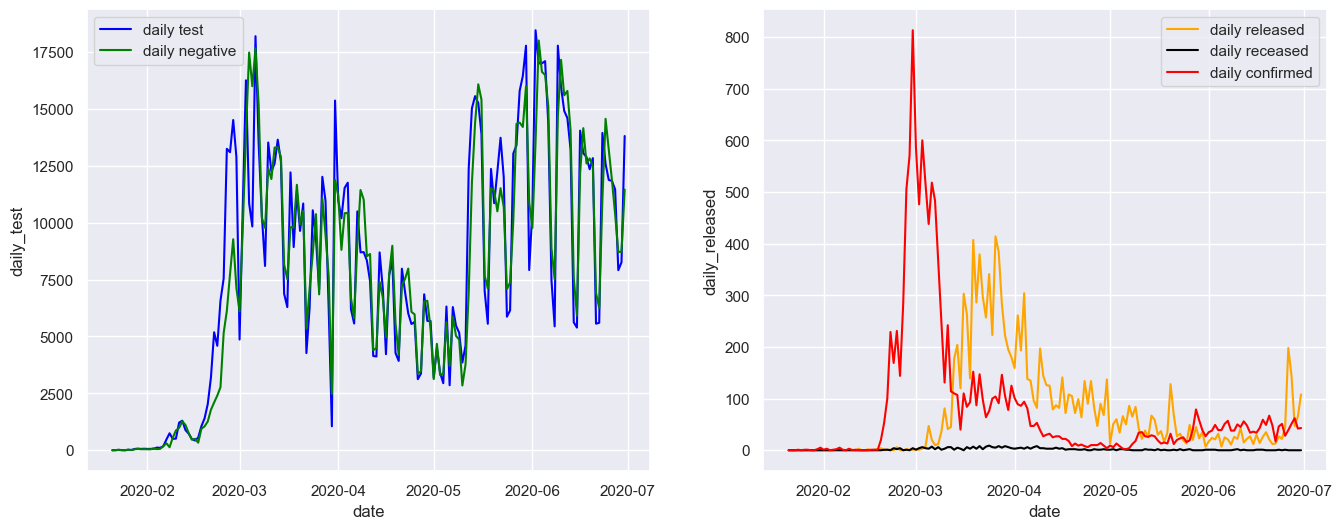

In [213]:
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

sns.lineplot(data=clean_time, x="date", y="daily_test", label="daily test", color="blue", ax=ax[0])
sns.lineplot(data=clean_time, x="date", y="daily_negative", label="daily negative", color="green", ax=ax[0])

sns.lineplot(data=clean_time, x="date", y="daily_released", label="daily released", color="orange", ax=ax[1])
sns.lineplot(data=clean_time, x="date", y="daily_deceased", label="daily receased", color="black", ax=ax[1])
sns.lineplot(data=clean_time, x="date", y="daily_confirmed", label="daily confirmed", color="red", ax=ax[1])

plt.show()

### TimeAge spreading

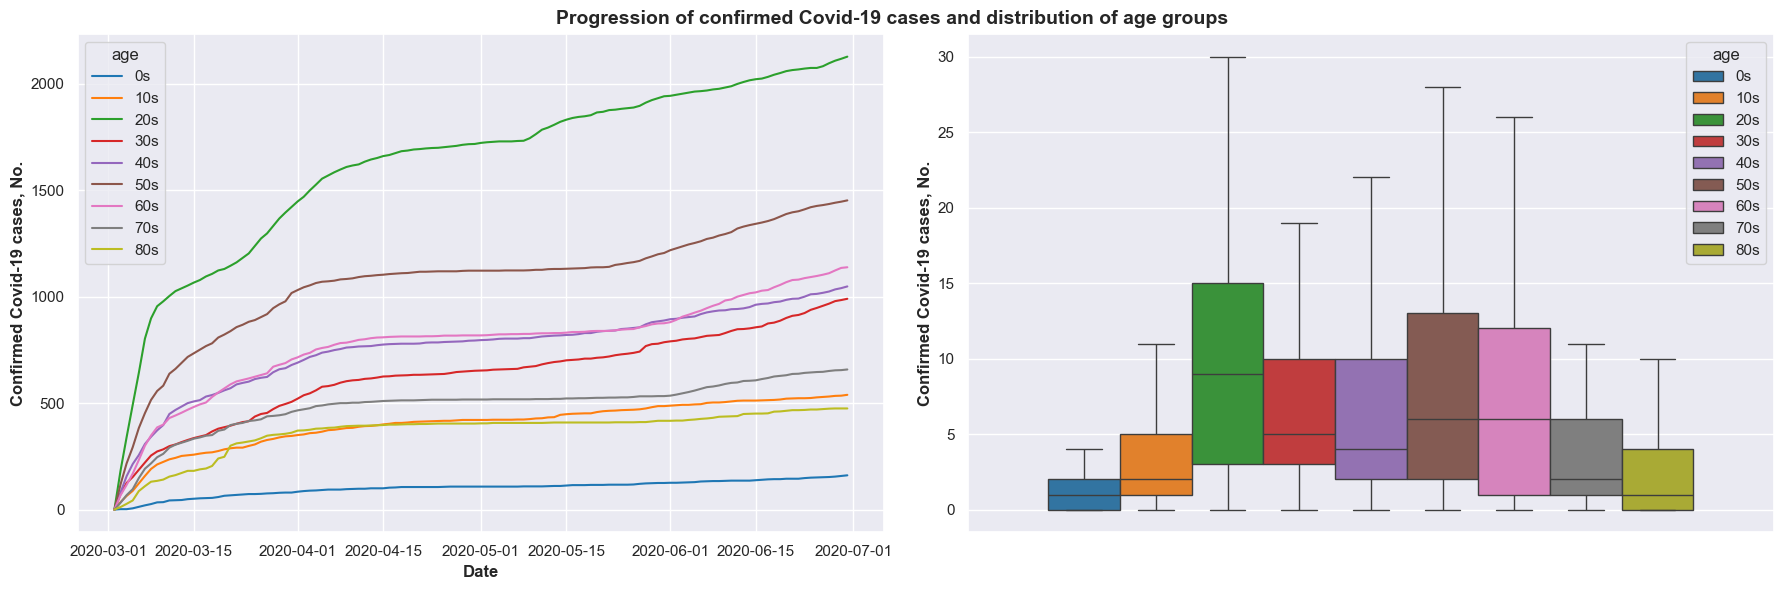

In [166]:
sns.set_style("darkgrid")
sns.set_context("notebook")
fig, ax = plt.subplots(1, 2, figsize=(18, 6))

sns.lineplot(data=clean_time_age, x="date", y="confirmed_cumsum", hue="age", ax=ax[0])
ax[0].set_xlabel("Date", fontweight="bold")
ax[0].set_ylabel("Confirmed Covid-19 cases, No.", fontweight="bold")

sns.boxplot(data=clean_time_age, y="daily_confirmed", hue="age", ax=ax[1], showfliers=False, flierprops=dict(markerfacecolor="red", marker="o"))
ax[1].set_ylabel("Confirmed Covid-19 cases, No.", fontweight="bold")

plt.tight_layout()
plt.subplots_adjust(top=0.94)
fig.suptitle(
    "Progression of confirmed Covid-19 cases and distribution of age groups",
    size=14,
    fontweight="bold",
    ha="center"
)

plt.show()

- The most progressive increase of confirmed cases each day  
has 20s age group;  
- Same group has the highest distribution of confirmed cases per day;  
- Strangely, second highest is the 50s group.

Grouped by age and Case Fatality Rate (CFR) calculated for each group

In [167]:
grouped_age = clean_time_age.groupby("age").agg({"confirmed":"max", "deceased":"max"})
grouped_age["cfr"] = round((grouped_age["deceased"] / grouped_age["confirmed"]) * 100, 2)
grouped_age

,confirmed,deceased,cfr
age,,,
0s,193,0,0.00
10s,708,0,0.00
20s,3362,0,0.00
30s,1496,2,0.13
40s,1681,3,0.18
50s,2286,15,0.66
60s,1668,41,2.46
70s,850,82,9.65
80s,556,139,25.00


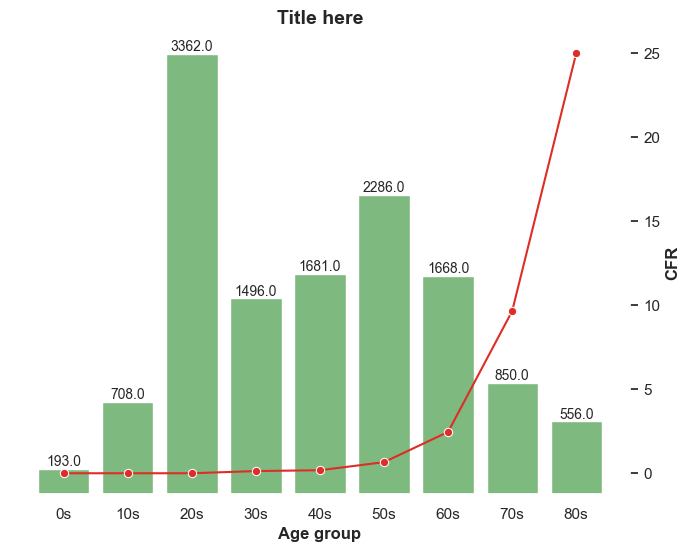

In [216]:
fig, ax = plt.subplots(figsize=(8, 6))

splot = sns.barplot(data=grouped_age, x="age", y="confirmed", color="#74c476")

def bar_annotations(name):
    for p in name.patches:
        name.annotate(format(p.get_height(), ".1f"),
                    (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha="center", va="center",
                    size=10,
                    xytext=(0, 5),
                    textcoords="offset points")
    return p

bar_annotations(splot)

ax.set_yticks([])
ax.set_ylabel(None)
ax.set_xlabel("Age group", fontweight="bold")
ax.set_frame_on(False)

ax2 = ax.twinx()

sns.lineplot(data=grouped_age, x="age", y="cfr", color="#de2d26", marker="o", ax=ax2)
ax2.grid(False)
ax2.set_ylabel("CFR", fontweight="bold")

plt.title(
    "Title here",
    size=14,
    fontweight="bold",
    ha="center")

plt.show()

- Low CFR in younger age groups. 0 to 20s have 0 reported deaths;  
This allows understanding that younger age individuals are less  
severely affected by covid19;  
- CFR tends to increase with age. Higher the age, higher CFR. Older individuals  
are more vulnerable to deceases;  
- 80s age group has the highest confirmed to deceased ratio indicating as  
the highest risk group;  
- Highest impact of confirmed cases has 20s group.

### TimeGender spreading

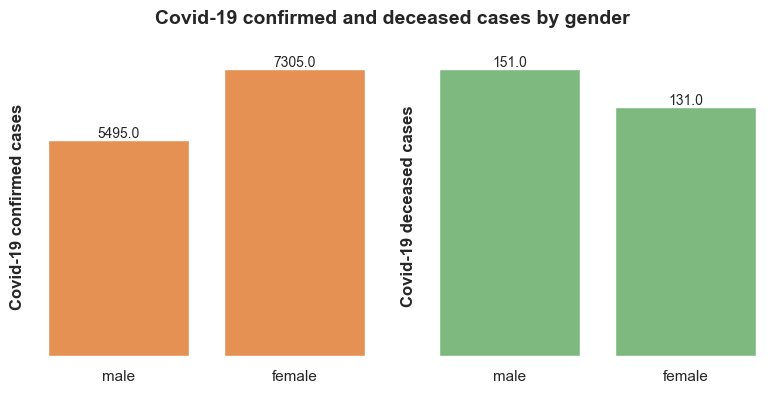

In [208]:
sns.set_style("darkgrid")
sns.set_context("notebook")
fig, ax = plt.subplots(1, 2, figsize=(8, 4))

sns.barplot(data=clean_time_gender, x="sex", y="confirmed", ax=ax[0], color="#fd8d3c", errorbar=None, estimator=max)
ax[0].set_xlabel(None)
ax[0].set_ylabel("Covid-19 confirmed cases", fontweight="bold")
ax[0].set_frame_on(False)
ax[0].set_yticks([])
bar_annotations(ax[0])

sns.barplot(data=clean_time_gender, x="sex", y="deceased", ax=ax[1], color="#74c476", errorbar=None, estimator=max)
ax[1].set_xlabel(None)
ax[1].set_ylabel("Covid-19 deceased cases", fontweight="bold")
ax[1].set_frame_on(False)
ax[1].set_yticks([])
bar_annotations(ax[1])

fig.suptitle(
    "Covid-19 confirmed and deceased cases by gender",
    size=14,
    fontweight="bold",
    ha="center"
)
plt.tight_layout()

plt.show()

In [190]:
grouped_gender = clean_time_gender.groupby("sex").agg({"confirmed":"max", "deceased":"max"})
grouped_gender.loc["total"] = {"confirmed":grouped_gender["confirmed"].sum(), "deceased":grouped_gender["deceased"].sum()}
grouped_gender["cfr"] = round((grouped_gender["deceased"] / grouped_gender["confirmed"]) * 100, 2)
grouped_gender

,confirmed,deceased,cfr
sex,,,
female,7305,131,1.79
male,5495,151,2.75
total,12800,282,2.20


In [209]:
total_confirmed = grouped_gender["confirmed"].loc["total"]
total_deceased = grouped_gender["deceased"].loc["total"]
cfr = grouped_gender["cfr"].loc["total"]
cfr_male = grouped_gender["cfr"].loc["male"]
cfr_female = grouped_gender["cfr"].loc["female"]

print(f"Total confirmed cases in period 2020-01 -- 2020-07 is: {total_confirmed}")
print(f"Total deceased cases in the same period is: {total_deceased}")
print(f"Total case fatality ratio (CFR) is: {cfr}%")
print(f"CFR male/female comparison: male({cfr_male}%) > female({cfr_female}%)")

Total confirmed cases in period 2020-01 -- 2020-07 is: 12800
Total deceased cases in the same period is: 282
Total case fatality ratio (CFR) is: 2.2%
CFR male/female comparison: male(2.75%) > female(1.79%)


In [136]:
seoul_floating

,date,hour,birth_year,sex,province,city,fp_num
0,2020-01-01,0,20,female,Seoul,Dobong-gu,19140
1,2020-01-01,0,20,male,Seoul,Dobong-gu,19950
2,2020-01-01,0,20,female,Seoul,Dongdaemun-gu,25450
3,2020-01-01,0,20,male,Seoul,Dongdaemun-gu,27050
4,2020-01-01,0,20,female,Seoul,Dongjag-gu,28880
...,...,...,...,...,...,...,...
1084795,2020-05-31,21,40,female,Seoul,Dobong-gu,27620
1084796,2020-05-31,21,40,female,Seoul,Songpa-gu,56560
1084797,2020-05-31,21,50,female,Seoul,Gangdong-gu,38960
1084798,2020-05-31,22,60,female,Seoul,Guro-gu,25420
